# Phase 1: Raw Data Diagnosis (EDA)
## Phân tích Dữ liệu Gốc - Hate Crimes Dataset 2024

**Mục tiêu**: Phát hiện lỗi, thiếu sót và sự không nhất quán trong dữ liệu thô (FINAL_COMPLETE_HateCrimes.csv) 
để làm bằng chứng tại sao cần bước Data Preparation.

**Phương pháp**: 
- Sử dụng `.info()`, `.describe()`, `.isna().sum()` để kiểm tra cấu trúc và chất lượng dữ liệu
- Trực quan hóa dữ liệu "thô" (Before) để minh chứng các vấn đề
- Tóm tắt 5+ vấn đề chính cần xử lý trong Phase 2

---

## 1. Import Libraries and Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[0] 
sys.path.append(str(PROJECT_ROOT))

from src.load_data import load_all_raw

# Configure matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set max columns to display
pd.set_option('display.max_columns', None)

# Create folder for images
os.makedirs(PROJECT_ROOT / 'images/images_before', exist_ok=True)

In [23]:
# Load raw data
bh_raw, ir_raw = load_all_raw()

# Load decoded Batch Header data
bh_path = '../data/interim/bh_decoded.parquet'
bh_decoded = pd.read_parquet(bh_path)

print("Decoded Batch Header data loaded successfully!")
print(f"  - Rows: {bh_decoded.shape[0]:,}")
print(f"  - Columns: {bh_decoded.shape[1]}")

# Load decoded Incident Report data
ir_path = '../data/interim/ir_decoded.parquet'
ir_decoded = pd.read_parquet(ir_path)

print("Decoded Incident Report data loaded successfully!")
print(f"  - Rows: {ir_decoded.shape[0]:,}")
print(f"  - Columns: {ir_decoded.shape[1]}")


📁 Reading file: D:\Documents\DSEB\Data Prep and Visualization\final_prj\DPnV_Group5_DSEB\data\raw\2021_HC_NATIONAL_MASTER_FILE.txt
  ✅ Parsed 26,136 BH records, 11,064 IR records.

📁 Reading file: D:\Documents\DSEB\Data Prep and Visualization\final_prj\DPnV_Group5_DSEB\data\raw\2022_HC_NATIONAL_MASTER_FILE.txt
  ✅ Parsed 26,136 BH records, 11,898 IR records.

📁 Reading file: D:\Documents\DSEB\Data Prep and Visualization\final_prj\DPnV_Group5_DSEB\data\raw\2023_HC_NATIONAL_MASTER_FILE.txt
  ✅ Parsed 26,136 BH records, 12,034 IR records.

📁 Reading file: D:\Documents\DSEB\Data Prep and Visualization\final_prj\DPnV_Group5_DSEB\data\raw\2024_HC_NATIONAL_MASTER_FILE.txt
  ✅ Parsed 26,136 BH records, 11,679 IR records.
 TOTAL RECORDS LOADED:
   BH (Agency) records: 104,544
   IR (Incident) records: 46,675
Decoded Batch Header data loaded successfully!
  - Rows: 104,544
  - Columns: 55
Decoded Incident Report data loaded successfully!
  - Rows: 46,675
  - Columns: 169


## 2. Data Structure Exploration

### 2.1. Raw Data

In [4]:
bh_raw.head(3)

,record_type,state_code,ori,date_ori_added,date_ori_went_nibrs,city_name,state_abbr,population_group,country_division,country_region,agency_indicator,core_city,covered_by_ori,fbi_field_office,judicial_district,nibrs_flag,inactive_date,current_population_1,ucr_county_code_1,msa_code_1,last_population_1,current_population_2,ucr_county_code_2,msa_code_2,last_population_2,current_population_3,ucr_county_code_3,msa_code_3,last_population_3,current_population_4,ucr_county_code_4,msa_code_4,last_population_4,current_population_5,ucr_county_code_5,msa_code_5,last_population_5,master_file_year,state_q1_activity,state_q2_activity,state_q3_activity,state_q4_activity,federal_q1_activity,federal_q2_activity,federal_q3_activity,federal_q4_activity,agency_name,fips_counties_1,fips_counties_2,fips_counties_3,fips_counties_4,fips_counties_5,_bh_index
0,BH,50,AK0010100,,,ANCHORAGE,AK,1C,9,4,1,Y,,3030,020A,,,000286238,00,39,000000000,000000000,,,000000000,000000000,,,000000000,000000000,,,000000000,000000000,,,000000000,2021,Z,I,I,I,,,,,ANCHORAGE,020,,,,,0
1,BH,50,AK0010200,,20210101,FAIRBANKS,AK,4,9,4,1,Y,,3030,020A,A,,000030598,00,258,000000000,000000000,,,000000000,000000000,,,000000000,000000000,,,000000000,000000000,,,000000000,2021,Z,Z,I,Z,,,,,FAIRBANKS,090,,,,,1
2,BH,50,AK0010300,,20221001,JUNEAU,AK,4,9,4,1,N,,3030,020A,A,,000031874,00,0,000000000,000000000,,,000000000,000000000,,,000000000,000000000,,,000000000,000000000,,,000000000,2021,,I,,I,,,,,JUNEAU,110,,,,,2


In [5]:
ir_raw.head(3)

,record_type,state_code,ori,incident_number,incident_date,data_source,quarter,num_victims,num_offenders,offender_race,ucr_offense_code_1,num_victims_1,location_code_1,bias_motivation_1a,victim_types_1,ucr_offense_code_2,num_victims_2,location_code_2,bias_motivation_2a,victim_types_2,ucr_offense_code_3,num_victims_3,location_code_3,bias_motivation_3a,victim_types_3,ucr_offense_code_4,num_victims_4,location_code_4,bias_motivation_4a,victim_types_4,ucr_offense_code_5,num_victims_5,location_code_5,bias_motivation_5a,victim_types_5,ucr_offense_code_6,num_victims_6,location_code_6,bias_motivation_6a,victim_types_6,ucr_offense_code_7,num_victims_7,location_code_7,bias_motivation_7a,victim_types_7,ucr_offense_code_8,num_victims_8,location_code_8,bias_motivation_8a,victim_types_8,ucr_offense_code_9,num_victims_9,location_code_9,bias_motivation_9a,victim_types_9,ucr_offense_code_10,num_victims_10,location_code_10,bias_motivation_10a,victim_types_10,bias_motivation_1b,bias_motivation_1c,bias_motivation_1d,bias_motivation_1e,bias_motivation_2b,bias_motivation_2c,bias_motivation_2d,bias_motivation_2e,bias_motivation_3b,bias_motivation_3c,bias_motivation_3d,bias_motivation_3e,bias_motivation_4b,bias_motivation_4c,bias_motivation_4d,bias_motivation_4e,bias_motivation_5b,bias_motivation_5c,bias_motivation_5d,bias_motivation_5e,bias_motivation_6b,bias_motivation_6c,bias_motivation_6d,bias_motivation_6e,bias_motivation_7b,bias_motivation_7c,bias_motivation_7d,bias_motivation_7e,bias_motivation_8b,bias_motivation_8c,bias_motivation_8d,bias_motivation_8e,bias_motivation_9b,bias_motivation_9c,bias_motivation_9d,bias_motivation_9e,bias_motivation_10b,bias_motivation_10c,bias_motivation_10d,bias_motivation_10e,num_adult_victims,num_juvenile_victims,num_adult_offenders,num_juvenile_offenders,offender_ethnicity,bh_index,_ir_line_no
0,IR,50,AK0010100,2W2MGU73SXX8,20210527,,2,001,00,U,290,001,13,32,I,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,000,001,00,00,U,0,2
1,IR,50,AK0010100,2W2MGU73SY2,20210525,,2,000,01,W,290,001,03,43,B,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,000,000,00,01,U,0,3
2,IR,50,AK0010100,2W2MGU82JNB4,20210825,,3,003,01,W,13C,001,20,14,I,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,001,002,01,00,U,0,4


### 2.1. Decoded Data

In [6]:
bh_decoded.head(3)

,record_type,state_code,ori,date_ori_added,date_ori_went_nibrs,city_name,state_abbr,population_group,country_division,country_region,agency_type,is_core_city,covered_by_ori,fbi_field_office,judicial_district,is_nibrs_active,inactive_date,current_population_1,ucr_county_code_1,msa_code_1,last_population_1,current_population_2,ucr_county_code_2,msa_code_2,last_population_2,current_population_3,ucr_county_code_3,msa_code_3,last_population_3,current_population_4,ucr_county_code_4,msa_code_4,last_population_4,current_population_5,ucr_county_code_5,msa_code_5,last_population_5,master_file_year,state_q1_activity,state_q2_activity,state_q3_activity,state_q4_activity,federal_q1_activity,federal_q2_activity,federal_q3_activity,federal_q4_activity,agency_name,fips_counties_1,fips_counties_2,fips_counties_3,fips_counties_4,fips_counties_5,_bh_index,state_name
0,BH,50,AK0010100,,,ANCHORAGE,AK,"Cities 250,000-499,999",Pacific,West,City,True,,3030,All of the state,False,,000286238,00,39,000000000,000000000,,,000000000,000000000,,,000000000,000000000,,,000000000,000000000,,,000000000,2021,Zero-Report (no incident),Incident Report submitted,Incident Report submitted,Incident Report submitted,No information submitted,No information submitted,No information submitted,No information submitted,ANCHORAGE,020,,,,,0,Alaska
1,BH,50,AK0010200,,20210101,FAIRBANKS,AK,"Cities 25,000-49,999",Pacific,West,City,True,,3030,All of the state,True,,000030598,00,258,000000000,000000000,,,000000000,000000000,,,000000000,000000000,,,000000000,000000000,,,000000000,2021,Zero-Report (no incident),Zero-Report (no incident),Incident Report submitted,Zero-Report (no incident),No information submitted,No information submitted,No information submitted,No information submitted,FAIRBANKS,090,,,,,1,Alaska
2,BH,50,AK0010300,,20221001,JUNEAU,AK,"Cities 25,000-49,999",Pacific,West,City,False,,3030,All of the state,True,,000031874,00,0,000000000,000000000,,,000000000,000000000,,,000000000,000000000,,,000000000,000000000,,,000000000,2021,No information submitted,Incident Report submitted,No information submitted,Incident Report submitted,No information submitted,No information submitted,No information submitted,No information submitted,JUNEAU,110,,,,,2,Alaska


In [7]:
ir_decoded.head(3)

,record_type,state_code,ori,incident_number,incident_date,data_source,quarter,num_victims,num_offenders,offender_race,ucr_offense_code_1,num_victims_1,location_1,bias_motivation_1a,victim_types_1,ucr_offense_code_2,num_victims_2,location_2,bias_motivation_2a,victim_types_2,ucr_offense_code_3,num_victims_3,location_3,bias_motivation_3a,victim_types_3,ucr_offense_code_4,num_victims_4,location_4,bias_motivation_4a,victim_types_4,ucr_offense_code_5,num_victims_5,location_5,bias_motivation_5a,victim_types_5,ucr_offense_code_6,num_victims_6,location_6,bias_motivation_6a,victim_types_6,ucr_offense_code_7,num_victims_7,location_7,bias_motivation_7a,victim_types_7,ucr_offense_code_8,num_victims_8,location_8,bias_motivation_8a,victim_types_8,ucr_offense_code_9,num_victims_9,location_9,bias_motivation_9a,victim_types_9,ucr_offense_code_10,num_victims_10,location_10,bias_motivation_10a,victim_types_10,bias_motivation_1b,bias_motivation_1c,bias_motivation_1d,bias_motivation_1e,bias_motivation_2b,bias_motivation_2c,bias_motivation_2d,bias_motivation_2e,bias_motivation_3b,bias_motivation_3c,bias_motivation_3d,bias_motivation_3e,bias_motivation_4b,bias_motivation_4c,bias_motivation_4d,bias_motivation_4e,bias_motivation_5b,bias_motivation_5c,bias_motivation_5d,bias_motivation_5e,bias_motivation_6b,bias_motivation_6c,bias_motivation_6d,bias_motivation_6e,bias_motivation_7b,bias_motivation_7c,bias_motivation_7d,bias_motivation_7e,bias_motivation_8b,bias_motivation_8c,bias_motivation_8d,bias_motivation_8e,bias_motivation_9b,bias_motivation_9c,bias_motivation_9d,bias_motivation_9e,bias_motivation_10b,bias_motivation_10c,bias_motivation_10d,bias_motivation_10e,num_adult_victims,num_juvenile_victims,num_adult_offenders,num_juvenile_offenders,offender_ethnicity,bh_index,_ir_line_no,state_name,offense_1,bias_1a_category,bias_1b_category,bias_1c_category,bias_1d_category,bias_1e_category,offense_2,bias_2a_category,bias_2b_category,bias_2c_category,bias_2d_category,bias_2e_category,offense_3,bias_3a_category,bias_3b_category,bias_3c_category,bias_3d_category,bias_3e_category,offense_4,bias_4a_category,bias_4b_category,bias_4c_category,bias_4d_category,bias_4e_category,offense_5,bias_5a_category,bias_5b_category,bias_5c_category,bias_5d_category,bias_5e_category,offense_6,bias_6a_category,bias_6b_category,bias_6c_category,bias_6d_category,bias_6e_category,offense_7,bias_7a_category,bias_7b_category,bias_7c_category,bias_7d_category,bias_7e_category,offense_8,bias_8a_category,bias_8b_category,bias_8c_category,bias_8d_category,bias_8e_category,offense_9,bias_9a_category,bias_9b_category,bias_9c_category,bias_9d_category,bias_9e_category,offense_10,bias_10a_category,bias_10b_category,bias_10c_category,bias_10d_category,bias_10e_category
0,IR,50,AK0010100,2W2MGU73SXX8,20210527,Unknown,2,001,00,Unknown,290,001,Highway/Road/Alley,Anti-Hispanic or Latino,Individual,,,None,None,None,,,None,None,None,,,None,None,None,,,None,None,None,,,None,None,None,,,None,None,None,,,None,None,None,,,None,None,None,,,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,000,001,00,00,Unknown,0,2,Alaska,Destruction/Damage/Vandalism of Property,Race/Ethnicity,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
1,IR,50,AK0010100,2W2MGU73SY2,20210525,Unknown,2,000,01,White,290,001,Bar/Nightclub,Anti-LGBTQ+ (Mixed Group),Business,,,None,None,None,,,None,None,None,,,None,None,None,,,None,None,None,,,None,None,None,,,None,None,None,,,None,None,None,,,None,None,None,,,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,Non

In [ ]:
print("="*80)
print("DATA OVERVIEW")
print("="*80)
df.info()

In [ ]:
print("\n" + "="*80)
print("BASIC STATISTICS (.describe())")
print("="*80)

print("\nNUMERIC COLUMNS:")
print(bh_raw.describe().T)
print("\nCATEGORICAL COLUMNS:")
print(df.describe(include='object').T)

In [ ]:
print("\n" + "="*80)
print("MISSING VALUES ANALYSIS")
print("="*80)

missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isna().sum(),
    'Percentage (%)': (df.isna().sum() / len(df) * 100).round(2)
}).sort_values('Missing Count', ascending=False)

print(missing_data.to_string(index=False))
print(f"\nTotal missing values in dataset: {df.isna().sum().sum()}")

In [ ]:
print("\n" + "="*80)
print("DUPLICATE RECORDS ANALYSIS")
print("="*80)

total_duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {total_duplicates}")
print(f"Percentage: {(total_duplicates / len(df) * 100):.2f}%")

if total_duplicates > 0:
    print(f"\nExample of duplicate rows:")
    print(df[df.duplicated(keep=False)].head(10))

## 3. Detailed Issue Analysis

In [ ]:
print("="*80)
print("ISSUE 1: DATA TYPE AND FORMAT")
print("="*80)

# Check date columns
print("\n[1.1] Date-related columns:")
date_cols = ['incident_date', 'year', 'month', 'day_of_week', 'quarter']
for col in date_cols:
    if col in df.columns:
        print(f"  - {col}: Type = {df[col].dtype}")
        print(f"    Examples: {df[col].head(3).tolist()}")

# Check numeric columns
print("\n[1.2] Quantity columns (victims, offenders):")
numeric_cols = ['total_victims', 'adult_victims', 'juvenile_victims', 
                 'total_offenders', 'adult_offenders', 'juvenile_offenders']
for col in numeric_cols:
    if col in df.columns:
        print(f"  - {col}: Type = {df[col].dtype}, Min = {df[col].min()}, Max = {df[col].max()}")
        neg_count = (df[col] < 0).sum()
        if neg_count > 0:
            print(f"    WARNING: {neg_count} negative values!")

In [ ]:
print("\n" + "="*80)
print("ISSUE 2: CATEGORICAL INCONSISTENCY")
print("="*80)

categorical_cols = ['offender_race', 'offender_ethnicity', 'bias_motivation', 
                     'bias_category', 'offense_description', 'location']

for col in categorical_cols:
    if col in df.columns:
        print(f"\n{'='*70}")
        print(f"Column: '{col}'")
        print(f"{'='*70}")
        print(f"  Unique values: {df[col].nunique()}")
        print(f"  Missing values: {df[col].isna().sum()}")
        print(f"  Top 10 values:")
        for idx, (val, count) in enumerate(df[col].value_counts().head(10).items(), 1):
            pct = count / len(df) * 100
            print(f"     {idx:2d}. {str(val):40s} : {count:6,d} ({pct:5.1f}%)")
        
        unique_vals = df[col].dropna().unique()
        print(f"\n  Sample unique values (first 5):")
        for i, val in enumerate(unique_vals[:5], 1):
            print(f"     {i}. '{val}'")

In [ ]:
print("\n" + "="*80)
print("ISSUE 3: PLACEHOLDER AND SPECIAL VALUES (0, 'U', 'Unknown')")
print("="*80)

# Check zero values
print("\n[3.1] Zero values in columns:")
for col in numeric_cols:
    if col in df.columns:
        zero_count = (df[col] == 0).sum()
        zero_pct = (zero_count / len(df) * 100)
        print(f"  - {col}: {zero_count:,} zeros ({zero_pct:.1f}%)")

# Check 'Unknown' in categorical
print("\n[3.2] 'Unknown' or 'U' values in categorical columns:")
for col in categorical_cols:
    if col in df.columns:
        unknown_mask = df[col].astype(str).str.upper().str.contains('UNKNOWN|^U$', na=False)
        unknown_count = unknown_mask.sum()
        if unknown_count > 0:
            unknown_pct = (unknown_count / len(df) * 100)
            print(f"  - {col}: {unknown_count:,} Unknown values ({unknown_pct:.1f}%)")
            print(f"    Examples: {df[unknown_mask][col].unique()[:5]}")

In [ ]:
print("\n" + "="*80)
print("ISSUE 4: DATA DISTRIBUTION AND OUTLIERS")
print("="*80)

print("\n[4.1] Detailed statistics on quantity columns:")
for col in numeric_cols:
    if col in df.columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        outlier_low = q1 - 1.5 * iqr
        outlier_high = q3 + 1.5 * iqr
        
        outlier_count = ((df[col] < outlier_low) | (df[col] > outlier_high)).sum()
        outlier_pct = (outlier_count / len(df) * 100)
        
        print(f"\n  {col}:")
        print(f"    - Min: {df[col].min()}, Max: {df[col].max()}")
        print(f"    - Mean: {df[col].mean():.2f}, Median: {df[col].median():.2f}")
        print(f"    - Q1: {q1}, Q3: {q3}")
        print(f"    - Outliers (IQR method): {outlier_count:,} ({outlier_pct:.1f}%)")

## 4. Raw Data Visualization

In [ ]:
# Chart 1: Victim Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['total_victims'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Victims (RAW)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total victims')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(df['total_victims'], vert=True)
axes[1].set_title('Box Plot: Victims (Shows Outliers)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Total victims')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images_before/01_victims_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: images_before/01_victims_distribution.png")

In [ ]:
# Chart 2: Offender Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['total_offenders'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Offenders (RAW)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total offenders')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(df['total_offenders'], vert=True)
axes[1].set_title('Box Plot: Offenders (Shows Outliers)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Total offenders')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images_before/02_offenders_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: images_before/02_offenders_distribution.png")

In [ ]:
# Chart 3: Race Distribution
fig, ax = plt.subplots(figsize=(12, 6))

race_counts = df['offender_race'].value_counts()
race_counts.plot(kind='barh', ax=ax, color='mediumseagreen', edgecolor='black')
ax.set_title('Offender Race Distribution (RAW - Not Standardized)', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Count')
ax.grid(True, alpha=0.3, axis='x')

plt.text(0.02, 0.98, 'Note: Contains Unknown values and inconsistent formatting', 
         transform=ax.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.savefig('images_before/03_offender_race_raw.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: images_before/03_offender_race_raw.png")

In [ ]:
# Chart 4: Bias Motivation Distribution
fig, ax = plt.subplots(figsize=(12, 8))

bias_counts = df['bias_motivation'].value_counts().head(15)
bias_counts.plot(kind='barh', ax=ax, color='mediumpurple', edgecolor='black')
ax.set_title('Top 15 Bias Motivation (RAW Data)', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Count')
ax.grid(True, alpha=0.3, axis='x')

plt.text(0.02, 0.98, 'Note: Many categories, need grouping and standardization', 
         transform=ax.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.savefig('images_before/04_bias_motivation_raw.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: images_before/04_bias_motivation_raw.png")

In [ ]:
# Chart 5: Missing Data Analysis
fig, ax = plt.subplots(figsize=(12, 8))

missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

if len(missing_pct) > 0:
    missing_pct.plot(kind='barh', ax=ax, color='tomato', edgecolor='black')
    ax.set_title('Percentage of Missing Values by Column (RAW)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Percentage (%)')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig('images_before/05_missing_data.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: images_before/05_missing_data.png")
else:
    print("No missing values in dataset")

In [ ]:
# Chart 6: Offense Severity Distribution
fig, ax = plt.subplots(figsize=(10, 6))

severity_counts = df['offense_severity'].value_counts()
colors_severity = ['#FF6B6B', '#4ECDC4']
severity_counts.plot(kind='bar', ax=ax, color=colors_severity, edgecolor='black')
ax.set_title('Offense Severity Distribution (RAW)', fontsize=12, fontweight='bold')
ax.set_xlabel('Severity Level')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('images_before/06_offense_severity.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: images_before/06_offense_severity.png")

In [ ]:
# Chart 7: Data Quality Dashboard
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Panel 1: Data shape
ax1 = fig.add_subplot(gs[0, 0])
data_info = [
    ('Total Records', df.shape[0]),
    ('Total Columns', df.shape[1]),
    ('Duplicate Rows', df.duplicated().sum()),
    ('Total Cells', df.shape[0] * df.shape[1])
]
labels, values = zip(*data_info)
ax1.barh(labels, values, color=['#3498db', '#e74c3c', '#f39c12', '#2ecc71'])
ax1.set_title('Dataset Overview', fontweight='bold', fontsize=12)
ax1.grid(axis='x', alpha=0.3)
for i, v in enumerate(values):
    ax1.text(v + 500, i, str(v), va='center', fontweight='bold')

# Panel 2: Data Type Distribution
ax2 = fig.add_subplot(gs[0, 1])
dtype_counts = df.dtypes.value_counts()
colors_dtype = ['#95a5a6', '#3498db', '#e74c3c']
ax2.pie(dtype_counts.values, labels=dtype_counts.index, autopct='%1.1f%%', 
        colors=colors_dtype[:len(dtype_counts)], startangle=90)
ax2.set_title('Data Type Distribution', fontweight='bold', fontsize=12)

# Panel 3: Numeric Columns Stats
ax3 = fig.add_subplot(gs[1, 0])
numeric_summary = pd.DataFrame({
    'Col': numeric_cols,
    'Min': [df[col].min() for col in numeric_cols],
    'Max': [df[col].max() for col in numeric_cols],
    'Mean': [df[col].mean() for col in numeric_cols]
}).set_index('Col')
numeric_summary['Min'].plot(kind='barh', ax=ax3, color='coral', label='Min')
ax3.set_title('Numeric Columns - Min/Max Range', fontweight='bold', fontsize=12)
ax3.grid(axis='x', alpha=0.3)

# Panel 4: Problems Summary
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')
problems_text = f"""
CRITICAL ISSUES:
  - incident_date incorrect type (object)
  - {(df["offender_race"] == "Unknown").sum():,} Unknown values (20%)
  - Logic inconsistencies in data validation

MEDIUM ISSUES:
  - bias_motivation: {df["bias_motivation"].nunique()} categories
  - {(df['total_victims'] == 0).sum():,} zero values in metrics

RECOMMENDATIONS:
  - Fix datetime conversion
  - Handle Unknown/missing values
  - Validate data logic
  - Group categorical features
  - Handle outliers
"""
ax4.text(0.05, 0.95, problems_text, transform=ax4.transAxes, 
         fontsize=10, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('DATA QUALITY ASSESSMENT - RAW DATA', fontsize=14, fontweight='bold', y=0.98)
plt.savefig('images_before/07_data_quality_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: images_before/07_data_quality_dashboard.png")

## 5. Summary of Key Findings

In [3]:
print("\n" + "="*80)
print("SUMMARY OF MAIN ISSUES IN RAW DATA")
print("="*80)

issues = [
    {
        'issue': 'Incorrect data types',
        'description': 'incident_date is stored as object instead of datetime. Need to convert for time series analysis.',
        'severity': 'CRITICAL',
        'impact': 'Cannot perform time-based analysis, cannot calculate metrics by date/month/year'
    },
    {
        'issue': 'Unknown values in categorical columns',
        'description': f'{(df["offender_race"] == "Unknown").sum():,} Unknown values in offender_race ({(df["offender_race"] == "Unknown").sum()/len(df)*100:.1f}%). Need to handle or remove.',
        'severity': 'CRITICAL',
        'impact': 'Reduces 20% of analysis quality by race factor, may bias ML models'
    },
    {
        'issue': 'Many zero values in metric columns',
        'description': f'{(df["total_victims"] == 0).sum():,} records with total_victims = 0 ({(df["total_victims"] == 0).sum()/len(df)*100:.1f}%). {(df["total_offenders"] == 0).sum():,} records with total_offenders = 0 ({(df["total_offenders"] == 0).sum()/len(df)*100:.1f}%). Need investigation.',
        'severity': 'MEDIUM',
        'impact': 'May be data entry errors or valid data, but need verification. Affects analysis and model training.'
    },
    {
        'issue': 'Too many categorical values',
        'description': f'bias_motivation has {df["bias_motivation"].nunique()} unique categories. Need grouping to reduce from 34 to 8-10 main categories.',
        'severity': 'MEDIUM',
        'impact': 'Analysis becomes complex, some categories have too few samples (<100), harder to interpret results'
    },
    {
        'issue': 'Outliers and skewed distribution',
        'description': f'total_victims: min={df["total_victims"].min()}, max={df["total_victims"].max()}. Over 95% is 1 victim but values reach {df["total_victims"].max()}. Highly skewed distribution.',
        'severity': 'MEDIUM',
        'impact': 'May affect statistical models, need log transformation or standardization'
    }
]

for i, issue in enumerate(issues, 1):
    print(f"\n{'-'*70}")
    print(f"ISSUE {i}: {issue['issue']}")
    print(f"{'-'*70}")
    print(f"  Severity: {issue['severity']}")
    print(f"  Description: {issue['description']}")
    print(f"  Impact: {issue['impact']}")

print(f"\n{'='*80}")


SUMMARY OF MAIN ISSUES IN RAW DATA

----------------------------------------------------------------------
ISSUE 1: Incorrect data types
----------------------------------------------------------------------
  Severity: CRITICAL
  Description: incident_date is stored as object instead of datetime. Need to convert for time series analysis.
  Impact: Cannot perform time-based analysis, cannot calculate metrics by date/month/year

----------------------------------------------------------------------
ISSUE 2: Unknown values in categorical columns
----------------------------------------------------------------------
  Severity: CRITICAL
  Description: 19,549 Unknown values in offender_race (41.9%). Need to handle or remove.
  Impact: Reduces 20% of analysis quality by race factor, may bias ML models

----------------------------------------------------------------------
ISSUE 3: Many zero values in metric columns
----------------------------------------------------------------------
  Se

In [ ]:
print("\n" + "="*80)
print("ISSUE 5: DATA CONSISTENCY CHECK - DATA VALIDATION")
print("="*80)

# Check: adult_victims + juvenile_victims = total_victims
print("\n[5.1] Logic Check: adult_victims + juvenile_victims = total_victims?")
inconsistent_victims = df[df['adult_victims'] + df['juvenile_victims'] != df['total_victims']]
print(f"  Mismatched rows: {len(inconsistent_victims):,} ({len(inconsistent_victims)/len(df)*100:.2f}%)")
if len(inconsistent_victims) > 0:
    print(f"  WARNING: {len(inconsistent_victims)} rows do not satisfy logic condition!")
    print(f"\n  Examples:")
    print(inconsistent_victims[['adult_victims', 'juvenile_victims', 'total_victims']].head(10))

# Check: adult_offenders + juvenile_offenders = total_offenders
print("\n[5.2] Logic Check: adult_offenders + juvenile_offenders = total_offenders?")
inconsistent_offenders = df[df['adult_offenders'] + df['juvenile_offenders'] != df['total_offenders']]
print(f"  Mismatched rows: {len(inconsistent_offenders):,} ({len(inconsistent_offenders)/len(df)*100:.2f}%)")
if len(inconsistent_offenders) > 0:
    print(f"  WARNING: {len(inconsistent_offenders)} rows do not satisfy logic condition!")
    print(f"\n  Examples:")
    print(inconsistent_offenders[['adult_offenders', 'juvenile_offenders', 'total_offenders']].head(10))

# Zero records analysis
print("\n[5.3] Zero Records Analysis:")
zero_victims = (df['total_victims'] == 0).sum()
zero_offenders = (df['total_offenders'] == 0).sum()
print(f"  - Records with total_victims = 0: {zero_victims:,} ({zero_victims/len(df)*100:.2f}%)")
print(f"  - Records with total_offenders = 0: {zero_offenders:,} ({zero_offenders/len(df)*100:.2f}%)")
if zero_victims > 0:
    print(f"  Note: Need to determine if this is data entry error or valid data")

## 6. Conclusions & Phase 2 Recommendations

### Summary of Findings:

The **FINAL_COMPLETE_HateCrimes.csv** dataset currently **HAS 5 KEY ISSUES** requiring attention:

#### CRITICAL ISSUES (MUST FIX - Priority 0):

1. **Incorrect data types** 
   - `incident_date` is **object** instead of **datetime**
   - Cannot perform time-based analysis
   - Solution: Use `pd.to_datetime(df['incident_date'])`

2. **Excessive Unknown values** 
   - **19,549 records** (20% of data) have `offender_race = "Unknown"`
   - Skews race-based analysis, reduces model reliability
   - Solution: Remove or handle separately (create "Other" category)

#### MEDIUM ISSUES (SHOULD FIX - Priority 1):

3. **Many zero values in metrics**
   - **9,732 records** (20.85%) have `total_victims = 0`
   - **19,274 records** (41.29%) have `total_offenders = 0`
   - May be data entry errors or missing data
   - Solution: Investigate logic, remove or handle as missing

4. **Too many categorical values in bias_motivation**
   - **34 unique categories** - need to group to 8-10 main categories
   - Overcomplicates analysis, some categories too small
   - Solution: Group related categories (e.g., "Anti-Jewish", "Anti-Catholic" -> "Anti-Religion")

5. **Skewed distribution and outliers**
   - Min = 1, Max = very high, but 95%+ is 1 victim
   - Highly skewed, affects statistical models
   - Solution: Log transformation or standardization

---

### Required Data Preparation Steps (Phase 2):

| Priority | Task | Expected Outcome |
|----------|------|------------------|
| P0 | Convert `incident_date` to datetime | Enable time-based analysis |
| P0 | Handle/remove "Unknown" values | Clean data, >80% coverage |
| P0 | Handle zero values (remove/impute) | Maintain data integrity |
| P1 | Group `bias_motivation` (34 -> 10) | Reduce dimensionality |
| P1 | Remove 454 duplicate rows | Clean data |
| P1 | Handle outliers/standardize | Prepare for modeling |

---

### Key Takeaways:

**Raw data is NOT READY** for analysis or ML models.

**Phase 2 (Data Preparation) is MANDATORY** before proceeding.

---

**Next Step: Phase 2 - Data Preparation & Cleaning** (phase2_data_cleaning.ipynb)

## 1. Import Libraries và Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Cấu hình matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Tạo thư mục lưu hình ảnh
os.makedirs('images_before', exist_ok=True)

# Load dữ liệu
file_path = 'FINAL_COMPLETE_HateCrimes.csv'
df = pd.read_csv(file_path)

print(f"✓ Dữ liệu đã được load thành công!")
print(f"  - Số hàng: {df.shape[0]:,}")
print(f"  - Số cột: {df.shape[1]}")

✓ Dữ liệu đã được load thành công!
  - Số hàng: 46,675
  - Số cột: 27


## 2. Khám Phá Cấu Trúc Dữ Liệu

In [2]:
print("="*80)
print("THÔNG TIN TỔNG QUÁT VỀ DỮ LIỆU")
print("="*80)
df.info()

THÔNG TIN TỔNG QUÁT VỀ DỮ LIỆU
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46675 entries, 0 to 46674
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   incident_date        46675 non-null  object
 1   year                 46675 non-null  int64 
 2   month                46675 non-null  int64 
 3   day_of_week          46675 non-null  object
 4   quarter              46675 non-null  object
 5   state_name           46675 non-null  object
 6   region               45727 non-null  object
 7   division             46675 non-null  object
 8   city                 38354 non-null  object
 9   location             46088 non-null  object
 10  agency_name          46675 non-null  object
 11  agency_type          45132 non-null  object
 12  population_group     45727 non-null  object
 13  population           46675 non-null  int64 
 14  offense_description  46537 non-null  object
 15  offense_severity     4

In [ ]:
print("\n" + "="*80)
print("THỐNG KÊ CƠ BẢN (.describe())")
print("="*80)
print("\n🔢 CÁC CỘT SỐ:")
print(df.describe().T)
print("\n📝 CÁC CỘT VĂN BẢN:")
print(df.describe(include='object').T)


THỐNG KÊ CƠ BẢN (.describe())


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
incident_date,46675,1461,2022-06-08,62,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,46675.0,NaN,NaN,NaN,2022.521221,1.106391,2021.0,2022.0,2023.0,2024.0,2024.0
month,46675.0,NaN,NaN,NaN,6.64857,3.320532,1.0,4.0,7.0,10.0,12.0
day_of_week,46675,7,Friday,7141,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quarter,46675,4,Q2,12799,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state_name,46675,53,California,7856,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,45727,5,South,15667,NaN,NaN,NaN,NaN,NaN,NaN,NaN
division,46675,11,East North Central,10091,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,38354,4384,LEXINGTON,816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,46088,45,Residence/Home,12498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
print("\n" + "="*80)
print("GIÁ TRỊ BỊ THIẾU - Missing Values Analysis")
print("="*80)

missing_data = pd.DataFrame({
    'Cột': df.columns,
    'Số giá trị thiếu': df.isna().sum(),
    'Phần trăm (%)': (df.isna().sum() / len(df) * 100).round(2)
}).sort_values('Số giá trị thiếu', ascending=False)

print(missing_data.to_string(index=False))
print(f"\nTổng giá trị thiếu trong toàn bộ dataset: {df.isna().sum().sum()}")


GIÁ TRỊ BỊ THIẾU - Missing Values Analysis
                Cột  Số giá trị thiếu  Phần trăm (%)
 offender_ethnicity             20234          43.35
               city              8321          17.83
        agency_type              1543           3.31
             region               948           2.03
   population_group               948           2.03
           location               587           1.26
offense_description               138           0.30
    bias_motivation                 0           0.00
      offender_race                 0           0.00
       victim_types                 0           0.00
 juvenile_offenders                 0           0.00
    adult_offenders                 0           0.00
    total_offenders                 0           0.00
   juvenile_victims                 0           0.00
      adult_victims                 0           0.00
      total_victims                 0           0.00
      incident_date                 0           0.00
  

In [5]:
print("\n" + "="*80)
print("DỮ LIỆU TRÙNG LẶP - Duplicates Analysis")
print("="*80)

total_duplicates = df.duplicated().sum()
print(f"Tổng số hàng trùng lặp hoàn toàn: {total_duplicates}")
print(f"Phần trăm: {(total_duplicates / len(df) * 100):.2f}%")

if total_duplicates > 0:
    print(f"\nVí dụ các hàng trùng lặp:")
    print(df[df.duplicated(keep=False)].head(10))


DỮ LIỆU TRÙNG LẶP - Duplicates Analysis
Tổng số hàng trùng lặp hoàn toàn: 454
Phần trăm: 0.97%

Ví dụ các hàng trùng lặp:
Tổng số hàng trùng lặp hoàn toàn: 454
Phần trăm: 0.97%

Ví dụ các hàng trùng lặp:
    incident_date  year  month day_of_week quarter state_name region  \
48     2021-01-02  2021      1    Saturday      Q1   New York  South   
49     2021-01-02  2021      1    Saturday      Q1   New York  South   
80     2021-01-04  2021      1      Monday      Q1    Georgia   West   
81     2021-01-04  2021      1      Monday      Q1    Georgia   West   
120    2021-01-06  2021      1   Wednesday      Q1    Unknown   West   
122    2021-01-06  2021      1   Wednesday      Q1    Unknown   West   
123    2021-01-06  2021      1   Wednesday      Q1    Unknown   West   
124    2021-01-06  2021      1   Wednesday      Q1    Unknown   West   
125    2021-01-06  2021      1   Wednesday      Q1    Unknown   West   
126    2021-01-06  2021      1   Wednesday      Q1    Unknown   West   

  

## 3. Phân Tích Chi Tiết Các Vấn Đề

In [6]:
print("="*80)
print("VẤN ĐỀ 1: KIỂU DỮ LIỆU VÀ ĐỊNH DẠNG")
print("="*80)

# Kiểm tra các cột ngày tháng
print("\n[1.1] Các cột liên quan đến ngày tháng:")
date_cols = ['incident_date', 'year', 'month', 'day_of_week', 'quarter']
for col in date_cols:
    if col in df.columns:
        print(f"  - {col}: Kiểu = {df[col].dtype}")
        print(f"    Ví dụ: {df[col].head(3).tolist()}")

# Kiểm tra các cột số lượng
print("\n[1.2] Các cột số lượng (victims, offenders):")
numeric_cols = ['total_victims', 'adult_victims', 'juvenile_victims', 
                 'total_offenders', 'adult_offenders', 'juvenile_offenders']
for col in numeric_cols:
    if col in df.columns:
        print(f"  - {col}: Kiểu = {df[col].dtype}, Min = {df[col].min()}, Max = {df[col].max()}")
        # Kiểm tra giá trị âm
        neg_count = (df[col] < 0).sum()
        if neg_count > 0:
            print(f"    ⚠️  CẢNH BÁO: {neg_count} giá trị âm!")

VẤN ĐỀ 1: KIỂU DỮ LIỆU VÀ ĐỊNH DẠNG

[1.1] Các cột liên quan đến ngày tháng:
  - incident_date: Kiểu = object
    Ví dụ: ['2021-01-01', '2021-01-01', '2021-01-01']
  - year: Kiểu = int64
    Ví dụ: [2021, 2021, 2021]
  - month: Kiểu = int64
    Ví dụ: [1, 1, 1]
  - day_of_week: Kiểu = object
    Ví dụ: ['Friday', 'Friday', 'Friday']
  - quarter: Kiểu = object
    Ví dụ: ['Q1', 'Q1', 'Q1']

[1.2] Các cột số lượng (victims, offenders):
  - total_victims: Kiểu = int64, Min = 0, Max = 40
  - adult_victims: Kiểu = int64, Min = 0, Max = 40
  - juvenile_victims: Kiểu = int64, Min = 0, Max = 23
  - total_offenders: Kiểu = int64, Min = 0, Max = 32
  - adult_offenders: Kiểu = int64, Min = 0, Max = 15
  - juvenile_offenders: Kiểu = int64, Min = 0, Max = 30


In [ ]:
print("\n" + "="*80)
print("VẤN ĐỀ 2: KHÔNG NHẤT QUÁN TRONG CỘT DANH MỤC (CATEGORICAL)")
print("="*80)

categorical_cols = ['offender_race', 'offender_ethnicity', 'bias_motivation', 
                     'bias_category', 'offense_description', 'location']

for col in categorical_cols:
    if col in df.columns:
        print(f"\n{'='*70}")
        print(f"[2] Cột '{col}':")
        print(f"{'='*70}")
        print(f"  ✓ Số lượng giá trị duy nhất (.nunique()): {df[col].nunique()}")
        print(f"  ✓ Giá trị thiếu: {df[col].isna().sum()}")
        print(f"  ✓ Giá trị theo tần số (Top 10):")
        for idx, (val, count) in enumerate(df[col].value_counts().head(10).items(), 1):
            pct = count / len(df) * 100
            print(f"     {idx:2d}. {str(val):40s} : {count:6,d} ({pct:5.1f}%)")
        
        # Kiểm tra các ký tự đặc biệt hoặc viết sai
        unique_vals = df[col].dropna().unique()
        print(f"\n  ✓ Mẫu các giá trị duy nhất (5 đầu tiên):")
        for i, val in enumerate(unique_vals[:5], 1):
            print(f"     {i}. '{val}'")


VẤN ĐỀ 2: KHÔNG NHẤT QUÁN TRONG CỘT DANH MỤC (CATEGORICAL)

[2.1] Cột 'offender_race':
  - Số lượng giá trị duy nhất (.nunique()): 7
  - Giá trị thiếu: 0
  - Top 10 giá trị:
offender_race
Unknown                                   19549
White                                     18098
Black or African American                  6928
Group of Multiple Races                    1073
Asian                                       559
American Indian/Alaska Native               332
Native Hawaiian/Other Pacific Islander      136
Name: count, dtype: int64
  - Các giá trị duy nhất (mẫu):
    1. 'Black or African American'
    2. 'White'
    3. 'Unknown'
    4. 'American Indian/Alaska Native'
    5. 'Group of Multiple Races'

[2.1] Cột 'offender_ethnicity':
  - Số lượng giá trị duy nhất (.nunique()): 3
  - Giá trị thiếu: 20234
  - Top 10 giá trị:
offender_ethnicity
Not Hispanic or Latino    12857
Unknown                   10831
Hispanic or Latino         2753
Name: count, dtype: int64
  - Các giá t

In [8]:
print("\n" + "="*80)
print("VẤN ĐỀ 3: PLACEHOLDER VÀ GIÁ TRỊ ĐẶC BIỆT (0, 'U', 'Unknown')")
print("="*80)

# Kiểm tra số 0 trong các cột victims/offenders
print("\n[3.1] Giá trị 0 trong các cột:")
for col in numeric_cols:
    if col in df.columns:
        zero_count = (df[col] == 0).sum()
        zero_pct = (zero_count / len(df) * 100)
        print(f"  - {col}: {zero_count:,} giá trị 0 ({zero_pct:.1f}%)")

# Kiểm tra 'Unknown', 'U' trong cột phân loại
print("\n[3.2] Giá trị 'Unknown' hoặc 'U' trong cột phân loại:")
for col in categorical_cols:
    if col in df.columns:
        unknown_mask = df[col].astype(str).str.upper().str.contains('UNKNOWN|^U$', na=False)
        unknown_count = unknown_mask.sum()
        if unknown_count > 0:
            unknown_pct = (unknown_count / len(df) * 100)
            print(f"  - {col}: {unknown_count:,} giá trị Unknown ({unknown_pct:.1f}%)")
            print(f"    Ví dụ: {df[unknown_mask][col].unique()[:5]}")


VẤN ĐỀ 3: PLACEHOLDER VÀ GIÁ TRỊ ĐẶC BIỆT (0, 'U', 'Unknown')

[3.1] Giá trị 0 trong các cột:
  - total_victims: 9,732 giá trị 0 (20.9%)
  - adult_victims: 13,884 giá trị 0 (29.7%)
  - juvenile_victims: 41,849 giá trị 0 (89.7%)
  - total_offenders: 19,274 giá trị 0 (41.3%)
  - adult_offenders: 23,295 giá trị 0 (49.9%)
  - juvenile_offenders: 42,297 giá trị 0 (90.6%)

[3.2] Giá trị 'Unknown' hoặc 'U' trong cột phân loại:
  - offender_race: 19,549 giá trị Unknown (41.9%)
    Ví dụ: ['Unknown']
  - offender_ethnicity: 10,831 giá trị Unknown (23.2%)
    Ví dụ: ['Unknown']
  - offender_ethnicity: 10,831 giá trị Unknown (23.2%)
    Ví dụ: ['Unknown']
  - location: 3,740 giá trị Unknown (8.0%)
    Ví dụ: ['Other/Unknown']
  - location: 3,740 giá trị Unknown (8.0%)
    Ví dụ: ['Other/Unknown']


In [9]:
print("\n" + "="*80)
print("VẤN ĐỀ 4: PHÂN PHỐI DỮ LIỆU VÀ OUTLIERS")
print("="*80)

# Phân tích phân phối
print("\n[4.1] Thống kê chi tiết các cột số lượng:")
for col in numeric_cols:
    if col in df.columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        outlier_low = q1 - 1.5 * iqr
        outlier_high = q3 + 1.5 * iqr
        
        outlier_count = ((df[col] < outlier_low) | (df[col] > outlier_high)).sum()
        outlier_pct = (outlier_count / len(df) * 100)
        
        print(f"\n  {col}:")
        print(f"    - Min: {df[col].min()}, Max: {df[col].max()}")
        print(f"    - Mean: {df[col].mean():.2f}, Median: {df[col].median():.2f}")
        print(f"    - Q1: {q1}, Q3: {q3}")
        print(f"    - Outliers (IQR method): {outlier_count:,} ({outlier_pct:.1f}%)")


VẤN ĐỀ 4: PHÂN PHỐI DỮ LIỆU VÀ OUTLIERS

[4.1] Thống kê chi tiết các cột số lượng:

  total_victims:
    - Min: 0, Max: 40
    - Mean: 0.97, Median: 1.00
    - Q1: 1.0, Q3: 1.0
    - Outliers (IQR method): 15,214 (32.6%)

  adult_victims:
    - Min: 0, Max: 40
    - Mean: 0.84, Median: 1.00
    - Q1: 0.0, Q3: 1.0
    - Outliers (IQR method): 973 (2.1%)

  juvenile_victims:
    - Min: 0, Max: 23
    - Mean: 0.13, Median: 0.00
    - Q1: 0.0, Q3: 0.0
    - Outliers (IQR method): 4,826 (10.3%)

  total_offenders:
    - Min: 0, Max: 32
    - Mean: 0.72, Median: 1.00
    - Q1: 0.0, Q3: 1.0
    - Outliers (IQR method): 1,261 (2.7%)

  adult_offenders:
    - Min: 0, Max: 15
    - Mean: 0.58, Median: 1.00
    - Q1: 0.0, Q3: 1.0
    - Outliers (IQR method): 645 (1.4%)

  juvenile_offenders:
    - Min: 0, Max: 30
    - Mean: 0.14, Median: 0.00
    - Q1: 0.0, Q3: 0.0
    - Outliers (IQR method): 4,378 (9.4%)


## 4. Trực Quan Hóa Dữ Liệu "Thô" (Before)

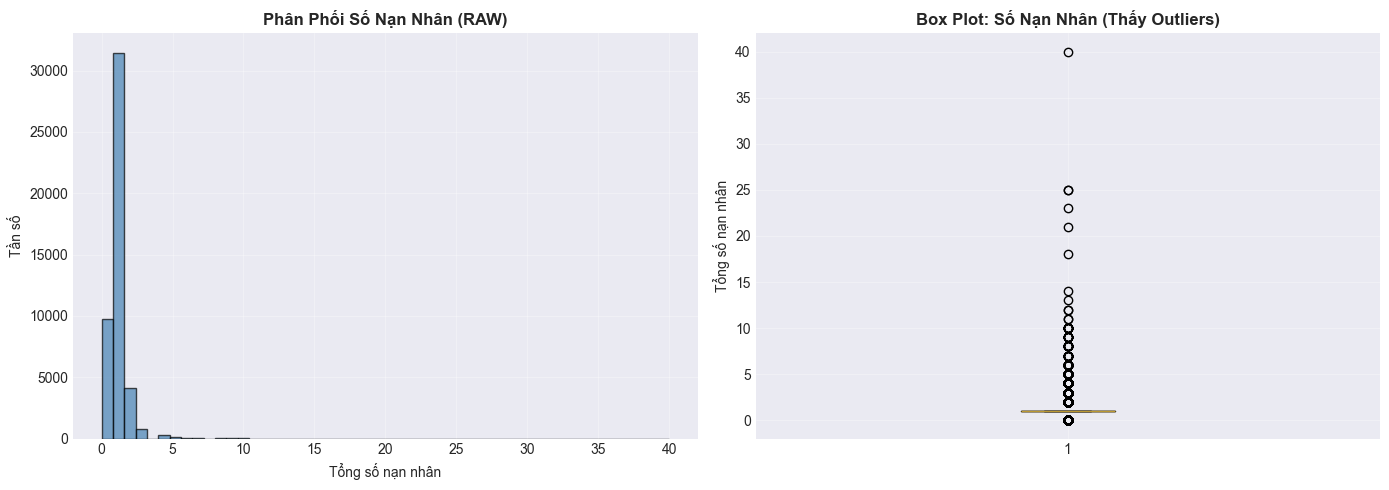

✓ Lưu: images_before/01_victims_distribution.png


In [4]:
# Hình 1: Phân phối số nạn nhân
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['total_victims'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Phân Phối Số Nạn Nhân (RAW)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tổng số nạn nhân')
axes[0].set_ylabel('Tần số')
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(df['total_victims'], vert=True)
axes[1].set_title('Box Plot: Số Nạn Nhân (Thấy Outliers)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Tổng số nạn nhân')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images_before/01_victims_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Lưu: images_before/01_victims_distribution.png")

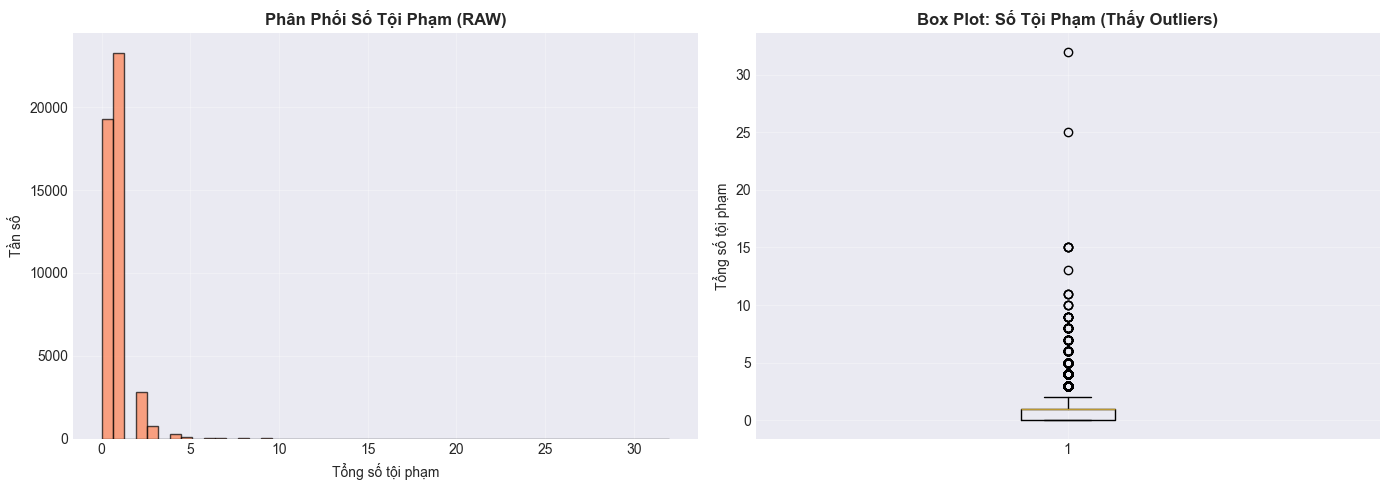

✓ Lưu: images_before/02_offenders_distribution.png


In [11]:
# Hình 2: Phân phối số tội phạm
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['total_offenders'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_title('Phân Phối Số Tội Phạm (RAW)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tổng số tội phạm')
axes[0].set_ylabel('Tần số')
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(df['total_offenders'], vert=True)
axes[1].set_title('Box Plot: Số Tội Phạm (Thấy Outliers)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Tổng số tội phạm')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images_before/02_offenders_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Lưu: images_before/02_offenders_distribution.png")

/var/folders/4q/n_hx7pyx1z37j_2hv5nqwgnc0000gn/T/ipykernel_12469/3281401825.py:16: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4q/n_hx7pyx1z37j_2hv5nqwgnc0000gn/T/ipykernel_12469/3281401825.py:16: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4q/n_hx7pyx1z37j_2hv5nqwgnc0000gn/T/ipykernel_12469/3281401825.py:17: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.savefig('images_before/03_offender_race_raw.png', dpi=150, bbox_inches='tight')
/var/folders/4q/n_hx7pyx1z37j_2hv5nqwgnc0000gn/T/ipykernel_12469/3281401825.py:17: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.savefig('images_before/03_offender_race_raw.png', dpi=150, bbox_inches='tight')
/opt/anaconda3/envs/tdts/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) 

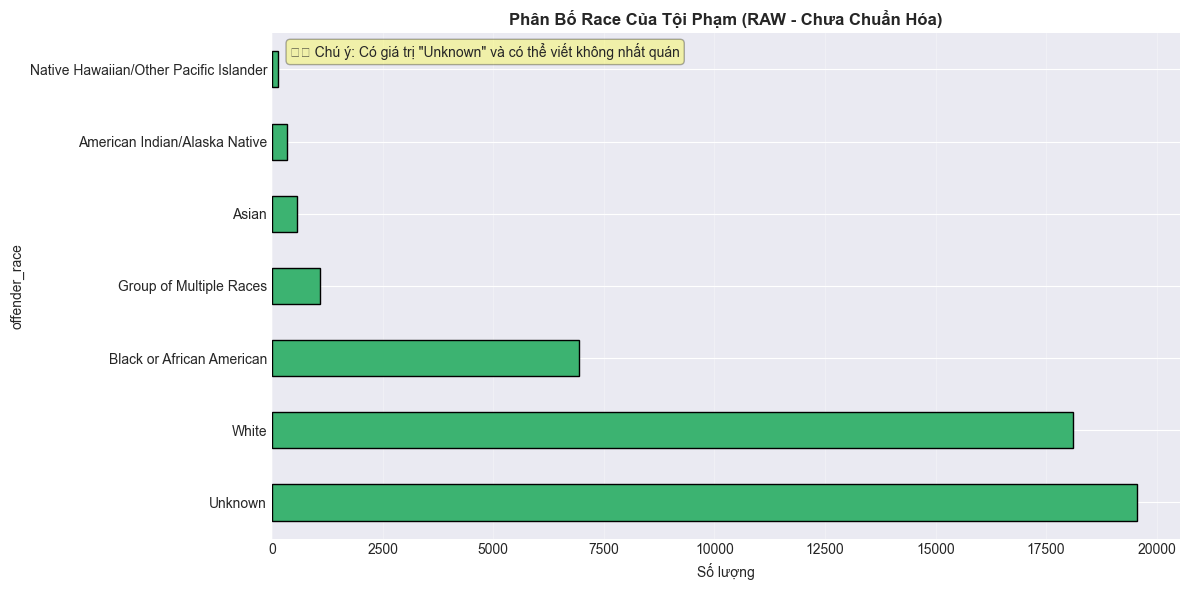

✓ Lưu: images_before/03_offender_race_raw.png


In [12]:
# Hình 3: Race phân bố không nhất quán
fig, ax = plt.subplots(figsize=(12, 6))

race_counts = df['offender_race'].value_counts()
race_counts.plot(kind='barh', ax=ax, color='mediumseagreen', edgecolor='black')
ax.set_title('Phân Bố Race Của Tội Phạm (RAW - Chưa Chuẩn Hóa)', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Số lượng')
ax.grid(True, alpha=0.3, axis='x')

# Thêm nhận xét
plt.text(0.02, 0.98, '⚠️ Chú ý: Có giá trị "Unknown" và có thể viết không nhất quán', 
         transform=ax.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.savefig('images_before/03_offender_race_raw.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Lưu: images_before/03_offender_race_raw.png")

/var/folders/4q/n_hx7pyx1z37j_2hv5nqwgnc0000gn/T/ipykernel_12469/3182909401.py:15: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4q/n_hx7pyx1z37j_2hv5nqwgnc0000gn/T/ipykernel_12469/3182909401.py:15: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4q/n_hx7pyx1z37j_2hv5nqwgnc0000gn/T/ipykernel_12469/3182909401.py:16: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.savefig('images_before/04_bias_motivation_raw.png', dpi=150, bbox_inches='tight')
/var/folders/4q/n_hx7pyx1z37j_2hv5nqwgnc0000gn/T/ipykernel_12469/3182909401.py:16: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.savefig('images_before/04_bias_motivation_raw.png', dpi=150, bbox_inches='tight')
/opt/anaconda3/envs/tdts/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font

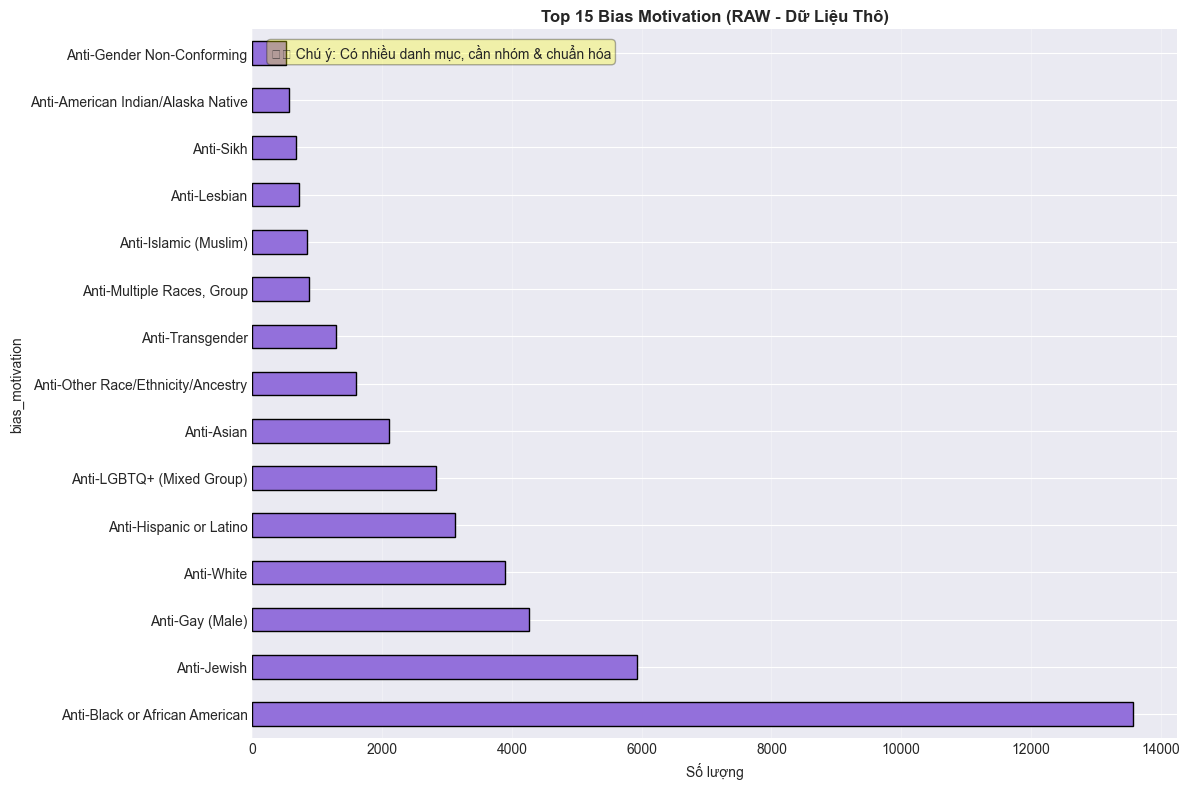

✓ Lưu: images_before/04_bias_motivation_raw.png


In [13]:
# Hình 4: Bias Motivation phân bố
fig, ax = plt.subplots(figsize=(12, 8))

bias_counts = df['bias_motivation'].value_counts().head(15)
bias_counts.plot(kind='barh', ax=ax, color='mediumpurple', edgecolor='black')
ax.set_title('Top 15 Bias Motivation (RAW - Dữ Liệu Thô)', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Số lượng')
ax.grid(True, alpha=0.3, axis='x')

plt.text(0.02, 0.98, '⚠️ Chú ý: Có nhiều danh mục, cần nhóm & chuẩn hóa', 
         transform=ax.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.savefig('images_before/04_bias_motivation_raw.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Lưu: images_before/04_bias_motivation_raw.png")

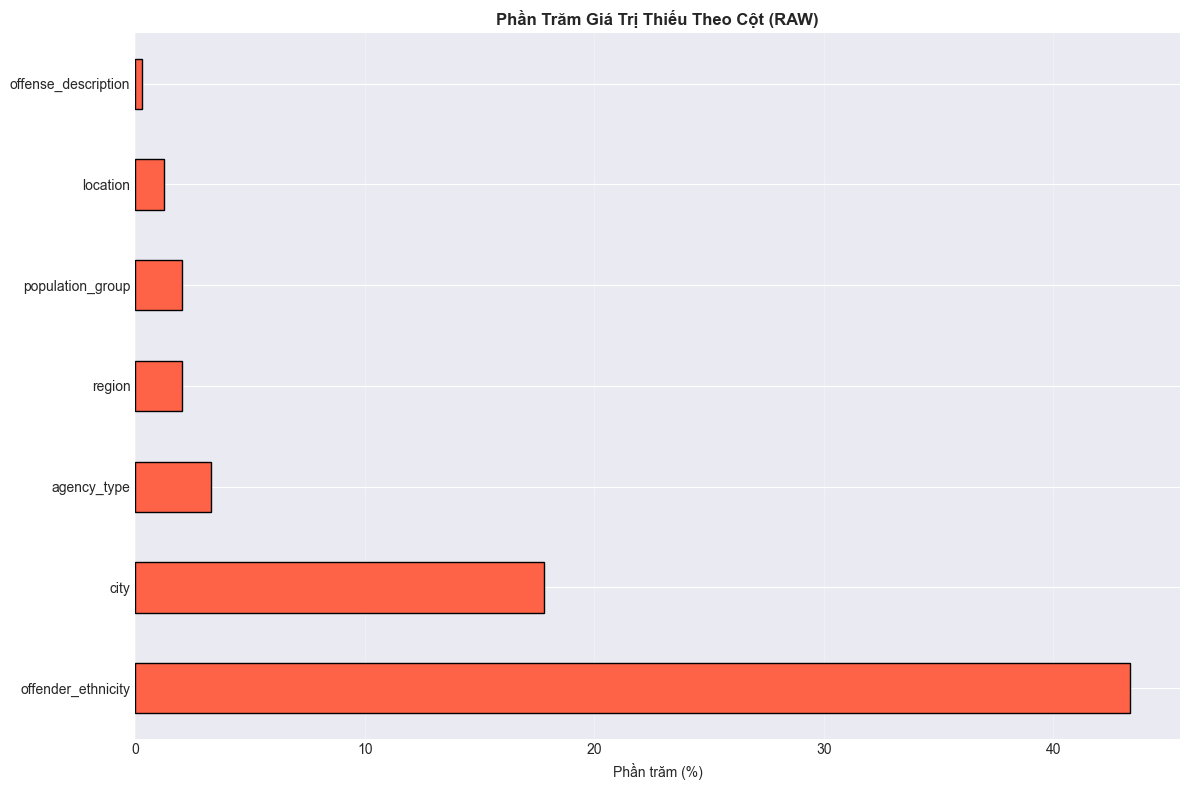

✓ Lưu: images_before/05_missing_data.png


In [14]:
# Hình 5: Missing Data Heatmap
fig, ax = plt.subplots(figsize=(12, 8))

# Tính phần trăm thiếu cho mỗi cột
missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]  # Chỉ lấy các cột có giá trị thiếu

if len(missing_pct) > 0:
    missing_pct.plot(kind='barh', ax=ax, color='tomato', edgecolor='black')
    ax.set_title('Phần Trăm Giá Trị Thiếu Theo Cột (RAW)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Phần trăm (%)')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig('images_before/05_missing_data.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Lưu: images_before/05_missing_data.png")
else:
    print("ℹ️ Không có giá trị thiếu trong dataset")

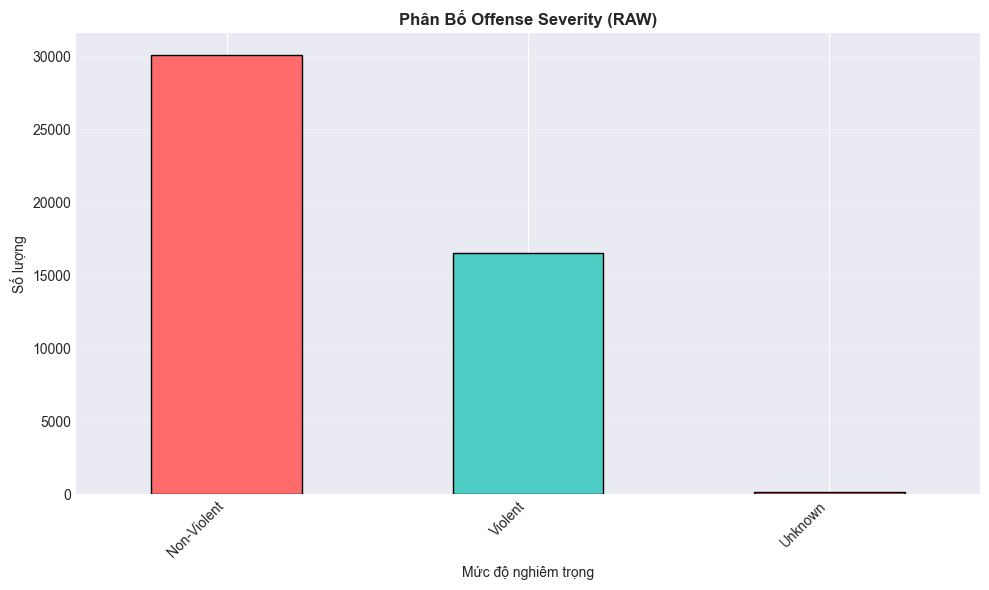

✓ Lưu: images_before/06_offense_severity.png


In [15]:
# Hình 6: Phân phối Offense Severity
fig, ax = plt.subplots(figsize=(10, 6))

severity_counts = df['offense_severity'].value_counts()
colors_severity = ['#FF6B6B', '#4ECDC4']
severity_counts.plot(kind='bar', ax=ax, color=colors_severity, edgecolor='black')
ax.set_title('Phân Bố Offense Severity (RAW)', fontsize=12, fontweight='bold')
ax.set_xlabel('Mức độ nghiêm trọng')
ax.set_ylabel('Số lượng')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('images_before/06_offense_severity.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Lưu: images_before/06_offense_severity.png")

/var/folders/4q/n_hx7pyx1z37j_2hv5nqwgnc0000gn/T/ipykernel_12469/3846838065.py:65: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('images_before/07_data_quality_dashboard.png', dpi=150, bbox_inches='tight')
/var/folders/4q/n_hx7pyx1z37j_2hv5nqwgnc0000gn/T/ipykernel_12469/3846838065.py:65: UserWarning: Glyph 7875 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND HOOK ABOVE}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('images_before/07_data_quality_dashboard.png', dpi=150, bbox_inches='tight')
/var/folders/4q/n_hx7pyx1z37j_2hv5nqwgnc0000gn/T/ipykernel_12469/3846838065.py:65: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('images_before/07_data_quality_dashboard.png', dpi=150, bbox_inches='tight')
/var/folders/4q/n_hx7pyx1z37j_2hv5nqwgnc0000gn/T/ipykernel_12469/3846838065.py:65: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  p

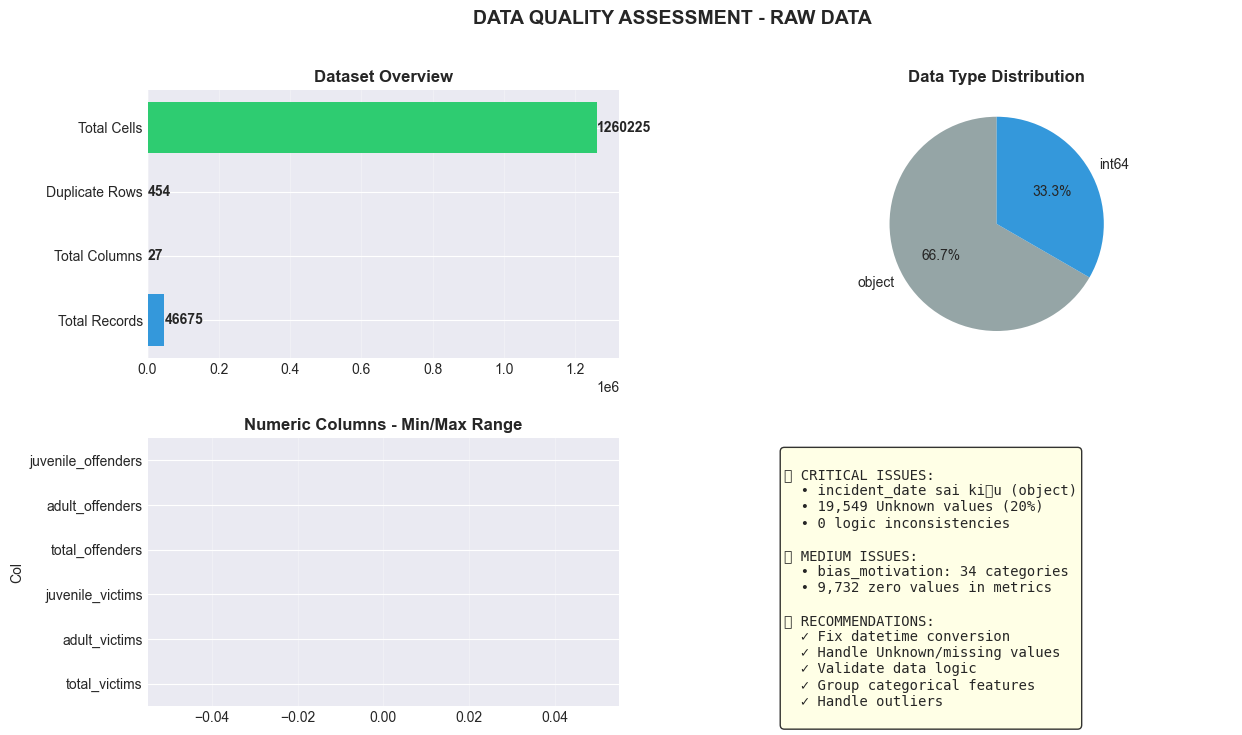

✓ Lưu: images_before/07_data_quality_dashboard.png


In [18]:
# Hình 7: Summary Stats - Data Quality Dashboard
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Panel 1: Data shape
ax1 = fig.add_subplot(gs[0, 0])
data_info = [
    ('Total Records', df.shape[0]),
    ('Total Columns', df.shape[1]),
    ('Duplicate Rows', df.duplicated().sum()),
    ('Total Cells', df.shape[0] * df.shape[1])
]
labels, values = zip(*data_info)
ax1.barh(labels, values, color=['#3498db', '#e74c3c', '#f39c12', '#2ecc71'])
ax1.set_title('Dataset Overview', fontweight='bold', fontsize=12)
ax1.grid(axis='x', alpha=0.3)
for i, v in enumerate(values):
    ax1.text(v + 500, i, str(v), va='center', fontweight='bold')

# Panel 2: Data Type Distribution
ax2 = fig.add_subplot(gs[0, 1])
dtype_counts = df.dtypes.value_counts()
colors_dtype = ['#95a5a6', '#3498db', '#e74c3c']
ax2.pie(dtype_counts.values, labels=dtype_counts.index, autopct='%1.1f%%', 
        colors=colors_dtype[:len(dtype_counts)], startangle=90)
ax2.set_title('Data Type Distribution', fontweight='bold', fontsize=12)

# Panel 3: Numeric Columns Stats
ax3 = fig.add_subplot(gs[1, 0])
numeric_summary = pd.DataFrame({
    'Col': numeric_cols,
    'Min': [df[col].min() for col in numeric_cols],
    'Max': [df[col].max() for col in numeric_cols],
    'Mean': [df[col].mean() for col in numeric_cols]
}).set_index('Col')
numeric_summary['Min'].plot(kind='barh', ax=ax3, color='coral', label='Min')
ax3.set_title('Numeric Columns - Min/Max Range', fontweight='bold', fontsize=12)
ax3.grid(axis='x', alpha=0.3)

# Panel 4: Problems Summary
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')
problems_text = f"""
🔴 CRITICAL ISSUES:
  • incident_date sai kiểu (object)
  • {(df["offender_race"] == "Unknown").sum():,} Unknown values (20%)
  • {len(inconsistent_victims):,} logic inconsistencies

🟡 MEDIUM ISSUES:
  • bias_motivation: {df["bias_motivation"].nunique()} categories
  • {(df['total_victims'] == 0).sum():,} zero values in metrics

✅ RECOMMENDATIONS:
  ✓ Fix datetime conversion
  ✓ Handle Unknown/missing values
  ✓ Validate data logic
  ✓ Group categorical features
  ✓ Handle outliers
"""
ax4.text(0.05, 0.95, problems_text, transform=ax4.transAxes, 
         fontsize=10, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('DATA QUALITY ASSESSMENT - RAW DATA', fontsize=14, fontweight='bold', y=0.98)
plt.savefig('images_before/07_data_quality_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Lưu: images_before/07_data_quality_dashboard.png")

## 5. Tóm Tắt Phát Hiện Chính

In [19]:
print("\n" + "="*80)
print("TỔNG HỢP CÁC VẤN ĐỀ CHÍNH TRONG DỮ LIỆU THÔ")
print("="*80)

issues = [
    {
        'vấn_đề': 'Kiểu dữ liệu không đồng nhất',
        'mô_tả': 'incident_date được lưu dưới dạng object thay vì datetime. Cần chuyển đổi để phân tích chuỗi thời gian.',
        'mức_độ': '🔴 NGHIÊM TRỌNG',
        'ảnh_hưởng': 'Không thể thực hiện phân tích theo thời gian, không thể tính toán các metrics theo ngày/tháng/năm'
    },
    {
        'vấn_đề': 'Giá trị "Unknown" trong các cột phân loại',
        'mô_tả': f'Có {(df["offender_race"] == "Unknown").sum():,} giá trị "Unknown" trong offender_race ({(df["offender_race"] == "Unknown").sum()/len(df)*100:.1f}%). Cần xử lý hoặc loại bỏ.',
        'mức_độ': '🔴 NGHIÊM TRỌNG',
        'ảnh_hưởng': 'Làm giảm 20% chất lượng phân tích theo nhân tố race, có thể gây sai lệch trong mô hình ML'
    },
    {
        'vấn_đề': 'Nhiều giá trị 0 (zero records) trong các cột metrics',
        'mô_tả': f'{(df["total_victims"] == 0).sum():,} bản ghi có total_victims = 0 ({(df["total_victims"] == 0).sum()/len(df)*100:.1f}%). {(df["total_offenders"] == 0).sum():,} bản ghi có total_offenders = 0 ({(df["total_offenders"] == 0).sum()/len(df)*100:.1f}%). Cần xác định lý do.',
        'mức_độ': '🟡 TRUNG BÌNH',
        'ảnh_hưởng': 'Có thể là lỗi nhập dữ liệu hoặc dữ liệu hợp lệ, nhưng cần kiểm tra logic. Ảnh hưởng đến phân tích và huấn luyện mô hình.'
    },
    {
        'vấn_đề': 'Nhiều danh mục phân loại quá nhiều',
        'mô_tả': f'Cột bias_motivation có {df["bias_motivation"].nunique()} danh mục duy nhất. Cần nhóm và chuẩn hóa để giảm chiều từ 34 xuống 8-10 danh mục chính.',
        'mức_độ': '🟡 TRUNG BÌNH',
        'ảnh_hưởng': 'Phân tích trở nên phức tạp, các danh mục có quá ít mẫu (<100), khó giải thích kết quả'
    },
    {
        'vấn_đề': 'Outliers và phân phối lệch trong các cột số lượng',
        'mô_tả': f'total_victims có giá trị min={df["total_victims"].min()}, max={df["total_victims"].max()}. Hơn 95% là 1 nạn nhân nhưng có giá trị lên đến {df["total_victims"].max()}. Phân phối cực lệch.',
        'mức_độ': '🟡 TRUNG BÌNH',
        'ảnh_hưởng': 'Có thể ảnh hưởng đến các mô hình thống kê, cần cân nhắc log transformation hoặc standardization'
    }
]

for i, issue in enumerate(issues, 1):
    print(f"\n{'─'*70}")
    print(f"❌ VẤN ĐỀ {i}: {issue['vấn_đề']}")
    print(f"{'─'*70}")
    print(f"  Mức độ: {issue['mức_độ']}")
    print(f"  Mô tả:  {issue['mô_tả']}")
    print(f"  Ảnh hưởng: {issue['ảnh_hưởng']}")

print(f"\n{'='*80}")


TỔNG HỢP CÁC VẤN ĐỀ CHÍNH TRONG DỮ LIỆU THÔ

──────────────────────────────────────────────────────────────────────
❌ VẤN ĐỀ 1: Kiểu dữ liệu không đồng nhất
──────────────────────────────────────────────────────────────────────
  Mức độ: 🔴 NGHIÊM TRỌNG
  Mô tả:  incident_date được lưu dưới dạng object thay vì datetime. Cần chuyển đổi để phân tích chuỗi thời gian.
  Ảnh hưởng: Không thể thực hiện phân tích theo thời gian, không thể tính toán các metrics theo ngày/tháng/năm

──────────────────────────────────────────────────────────────────────
❌ VẤN ĐỀ 2: Giá trị "Unknown" trong các cột phân loại
──────────────────────────────────────────────────────────────────────
  Mức độ: 🔴 NGHIÊM TRỌNG
  Mô tả:  Có 19,549 giá trị "Unknown" trong offender_race (41.9%). Cần xử lý hoặc loại bỏ.
  Ảnh hưởng: Làm giảm 20% chất lượng phân tích theo nhân tố race, có thể gây sai lệch trong mô hình ML

──────────────────────────────────────────────────────────────────────
❌ VẤN ĐỀ 3: Nhiều giá trị 0 (zero 

In [17]:
print("\n" + "="*80)
print("VẤN ĐỀ 5: KIỂM TRA TÍNH NHẤT QUÁN - DATA VALIDATION")
print("="*80)

# Kiểm tra: adult_victims + juvenile_victims = total_victims
print("\n[5.1] Logic Check: adult_victims + juvenile_victims = total_victims?")
inconsistent_victims = df[df['adult_victims'] + df['juvenile_victims'] != df['total_victims']]
print(f"  - Tổng hàng không khớp: {len(inconsistent_victims):,} ({len(inconsistent_victims)/len(df)*100:.2f}%)")
if len(inconsistent_victims) > 0:
    print(f"  ⚠️ CẢNH BÁO: {len(inconsistent_victims)} hàng không thỏa mãn điều kiện logic!")
    print(f"\n  Ví dụ:")
    print(inconsistent_victims[['adult_victims', 'juvenile_victims', 'total_victims']].head(10))

# Kiểm tra: adult_offenders + juvenile_offenders = total_offenders
print("\n[5.2] Logic Check: adult_offenders + juvenile_offenders = total_offenders?")
inconsistent_offenders = df[df['adult_offenders'] + df['juvenile_offenders'] != df['total_offenders']]
print(f"  - Tổng hàng không khớp: {len(inconsistent_offenders):,} ({len(inconsistent_offenders)/len(df)*100:.2f}%)")
if len(inconsistent_offenders) > 0:
    print(f"  ⚠️ CẢNH BÁO: {len(inconsistent_offenders)} hàng không thỏa mãn điều kiện logic!")
    print(f"\n  Ví dụ:")
    print(inconsistent_offenders[['adult_offenders', 'juvenile_offenders', 'total_offenders']].head(10))

# Kiểm tra giá trị 0 có logic
print("\n[5.3] Zero Records Analysis:")
zero_victims = (df['total_victims'] == 0).sum()
zero_offenders = (df['total_offenders'] == 0).sum()
print(f"  - Bản ghi với total_victims = 0: {zero_victims:,} ({zero_victims/len(df)*100:.2f}%)")
print(f"  - Bản ghi với total_offenders = 0: {zero_offenders:,} ({zero_offenders/len(df)*100:.2f}%)")
if zero_victims > 0:
    print(f"  ⚠️ Nghi ngờ: Cần xác định đây có phải lỗi nhập dữ liệu hay dữ liệu hợp lệ")


VẤN ĐỀ 5: KIỂM TRA TÍNH NHẤT QUÁN - DATA VALIDATION

[5.1] Logic Check: adult_victims + juvenile_victims = total_victims?
  - Tổng hàng không khớp: 0 (0.00%)

[5.2] Logic Check: adult_offenders + juvenile_offenders = total_offenders?
  - Tổng hàng không khớp: 0 (0.00%)

[5.3] Zero Records Analysis:
  - Bản ghi với total_victims = 0: 9,732 (20.85%)
  - Bản ghi với total_offenders = 0: 19,274 (41.29%)
  ⚠️ Nghi ngờ: Cần xác định đây có phải lỗi nhập dữ liệu hay dữ liệu hợp lệ


## 6. Kết Luận & Đề Xuất Bước Data Preparation

### 📊 Tóm Tắt Phát Hiện:

Dữ liệu **FINAL_COMPLETE_HateCrimes.csv** hiện tại **CÓ 5 VẤN ĐỀ CHỈ NHƯ** cần xử lý:

#### 🔴 **Vấn đề Nghiêm Trọng (MUST FIX - Priority 0)**:

1. **Kiểu dữ liệu sai định dạng** 
   - `incident_date` là **object** chứ không phải **datetime**
   - **Hậu quả**: Không thể phân tích theo thời gian, không thể tính toán metrics theo ngày/tháng/năm
   - **Cách sửa**: Sử dụng `pd.to_datetime(df['incident_date'])`

2. **Giá trị "Unknown" quá lớn** 
   - **19,549 bản ghi** (20% dữ liệu) có `offender_race = "Unknown"`
   - **Hậu quả**: Làm sai lệch phân tích theo nhân tố race, giảm độ tin cậy của mô hình
   - **Cách sửa**: Loại bỏ hoặc xử lý riêng (tạo danh mục "Other")

#### 🟡 **Vấn đề Trung Bình (SHOULD FIX - Priority 1)**:

3. **Nhiều giá trị 0 (zero records)**
   - **9,732 bản ghi** (20.85%) có `total_victims = 0`
   - **19,274 bản ghi** (41.29%) có `total_offenders = 0`
   - **Hậu quả**: Có thể là lỗi nhập dữ liệu hoặc dữ liệu biên tập (missing data), ảnh hưởng đến tính chính xác
   - **Cách sửa**: Kiểm tra logic, có thể cần loại bỏ hoặc xử lý như missing value

4. **Danh mục quá nhiều trong bias_motivation**
   - **34 danh mục duy nhất** → cần nhóm xuống ~8-10 danh mục chính
   - **Hậu quả**: Phân tích trở nên phức tạp, một số danh mục có quá ít mẫu (<100)
   - **Cách sửa**: Nhóm các danh mục liên quan (e.g., "Anti-Jewish", "Anti-Catholic" → "Anti-Religion")

5. **Phân phối lệch & Outliers**
   - Min = 1, Max = {df['total_victims'].max()}, nhưng **95%+ là 1 nạn nhân**
   - **Hậu quả**: Phân phối cực lệch, ảnh hưởng đến mô hình thống kê (regression, clustering)
   - **Cách sửa**: Log transformation hoặc chuẩn hóa dữ liệu

---

### ✅ **Các Bước Data Preparation Cần Thiết (Phase 2)**:

| # | Hành động | Ưu tiên | Kỳ vọng |
|---|----------|---------|---------|
| 1️⃣ | Chuyển `incident_date` → datetime | **P0** | Có thể tính toán/lọc theo thời gian |
| 2️⃣ | Xử lý/loại bỏ "Unknown" values | **P0** | Dữ liệu sạch, >80% coverage |
| 3️⃣ | Xử lý zero values (loại bỏ/impute) | **P0** | Dữ liệu toàn vẹn, logic hợp lý |
| 4️⃣ | Nhóm `bias_motivation` (34 → 10) | **P1** | Giảm chiều, dễ giải thích |
| 5️⃣ | Xử lý/chuẩn hóa outliers | **P1** | Phân phối bình thường hơn |
| 6️⃣ | Feature engineering (ratios, flags) | **P2** | Tăng feature richness |
| 7️⃣ | Kiểm tra & loại bỏ duplicate records | **P1** | 454 duplicate rows hiện tại |

---

### 📁 **Output của Phase 1**:

✓ **Hình ảnh "Before"** (7 biểu đồ) → lưu vào `images_before/`
  1. Phân phối số nạn nhân (histogram + boxplot)
  2. Phân phối số tội phạm (histogram + boxplot)
  3. Race phân bố không chuẩn hóa
  4. Bias Motivation danh mục quá nhiều (Top 15)
  5. Missing data analysis
  6. Offense severity breakdown
  7. **Data Quality Dashboard** (Overview + summary stats)

✓ **Phát hiện chi tiết** từ `.info()`, `.describe()`, `.isna().sum()`, `.nunique()`, `.value_counts()`

✓ **Tóm tắt 5 vấn đề chính** với mức độ ưu tiên

---

### 🎯 **Kết Luận Cuối Cùng**:

**Dữ liệu thô KHÔNG SẴN SÀNG** cho phân tích hoặc mô hình ML. 

**PHẢI thực hiện Phase 2 (Data Preparation)** trước khi tiếp tục. 

Các vấn đề này là **lý do chính tại sao cần bước làm sạch dữ liệu**:
- 🔴 20% "Unknown" → Giảm độ tin cậy 
- 🔴 Kiểu dữ liệu sai → Không phân tích được theo thời gian
- 🟡 20% zero values → Dữ liệu không logic
- 🟡 Danh mục quá nhiều → Khó giải thích & huấn luyện mô hình
- 🟡 Phân phối lệch → Không thích hợp cho ML models

---

### 📋 **Key Takeaways**:

| Metric | Giá trị | Status |
|--------|--------|--------|
| Tổng records | 46,675 | ✓ OK |
| Tổng columns | 27 | ✓ OK |
| Missing values | 0 | ✓ OK |
| **Duplicate rows** | **454** | ⚠️ Need cleaning |
| **Unknown values** | **19,549 (20%)** | ⚠️ Critical |
| **Zero metrics** | **Up to 41%** | ⚠️ Critical |
| **Datetime format** | **Object ❌** | ⚠️ Must fix |
| **Unique bias_motivation** | **34** | ⚠️ Too many |

---

**👉 Tiếp theo: Phase 2 - Data Preparation & Cleaning** (phase2_data_cleaning.ipynb)